#### Nathaniel Linden - 2024-10-27

In [33]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import sys, json
import met_brewer as mb
from matplotlib.colors import LinearSegmentedColormap
import jax

# set plot style and import helper functions
plt.style.use('custom')
mpl.rcParams['figure.autolayout'] = True
colors = mb.met_brew(name="Veronese", n=7)

# plotting helper functions
# add odes code
sys.path.append('../ampk_models/')
from plotting_helper_funcs import *

# set Jax to use 64-bit precision and CPU
jax.config.update('jax_enable_x64', True)
jax.config.update('jax_platform_name', 'cpu')

save_path = '../../results/MA_v_MM/'

Load data + results

In [34]:
# pyruvate kinase data
pyr_kin_dat = pd.read_csv('./data/Duggleby_Clarke_1991_Fig2.csv')
times = pyr_kin_dat['time'].to_numpy()
data = pyr_kin_dat['conc (mM)'].to_numpy()

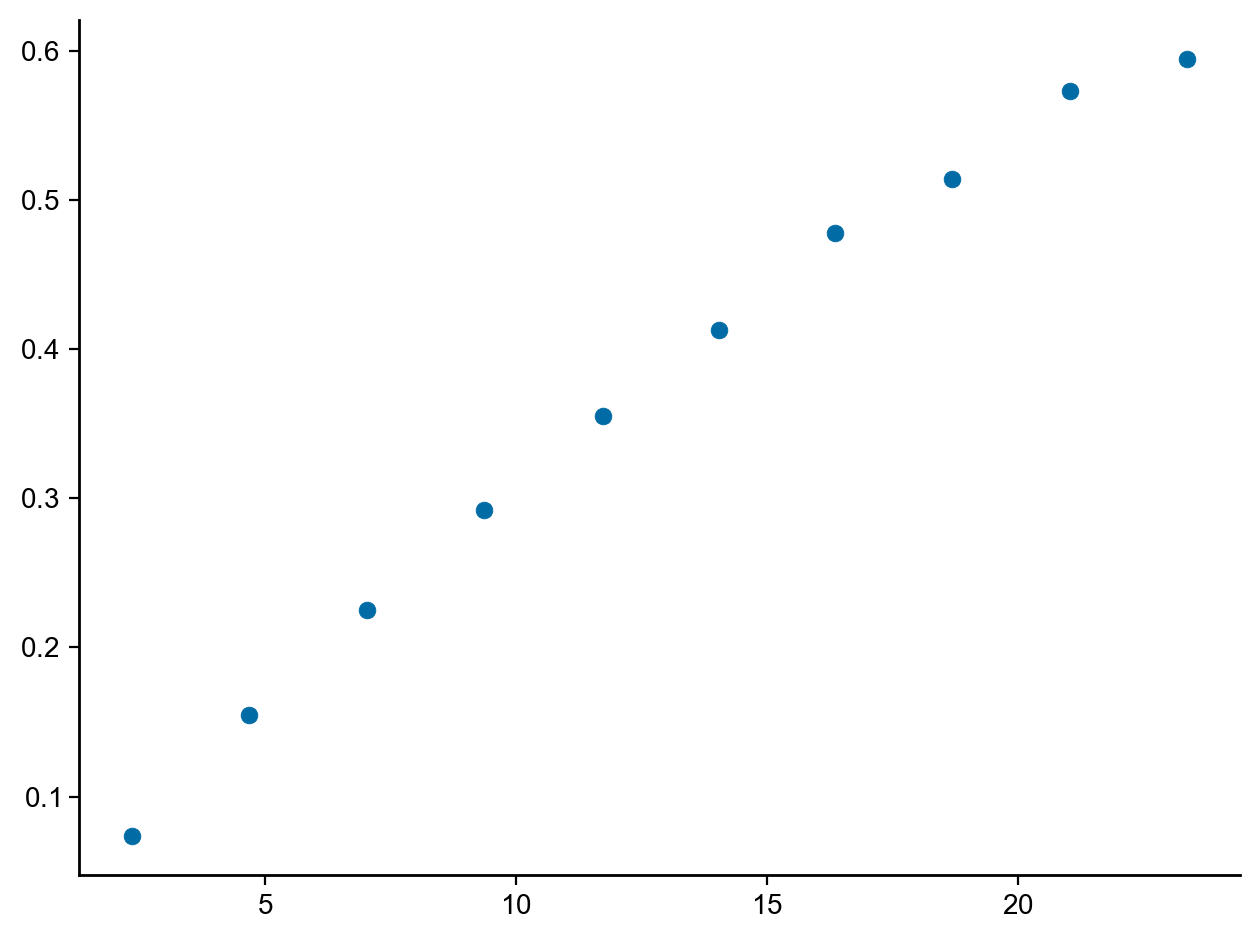

In [35]:
fig, ax = plt.subplots()
ax.scatter(times, data)

In [36]:
# load inferences
inf_data_MA = az.from_netcdf('./results/MA_mcmc_samples.nc')
inf_data_MM = az.from_netcdf('./results/MM_mcmc_samples.nc')
inf_data_Hill = az.from_netcdf('./results/Hill_mcmc_samples.nc')

In [39]:
# az.plot_trace(inf_data_Hill)
MA = az.plot_trace(inf_data_MA, figsize=(7, 4), compact=True)
for ax in MA.ravel():
    # ax.set_xticklabels(fontsize=8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(8)
    ax.ticklabel_format(style='plain', axis='x')

plt.savefig(save_path + 'MA_trace.png', dpi=300)
plt.close()

MM = az.plot_trace(inf_data_MM, figsize=(7, 4), compact=True)
for ax in MM.ravel():
    # ax.set_xticklabels(fontsize=8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(8)
    ax.ticklabel_format(style='plain', axis='x')

plt.savefig(save_path + 'MM_trace.png', dpi=300)
plt.close()

hill = az.plot_trace(inf_data_Hill, figsize=(7, 4), compact=True)
for ax in hill.ravel():
    # ax.set_xticklabels(fontsize=8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(8)
    ax.ticklabel_format(style='plain', axis='x')

plt.savefig(save_path + 'hill_trace.png', dpi=300)
plt.close()

/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_91947/1985539263.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_path + 'MA_hist.pdf', transparent=True, bbox_inches='tight')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_91947/1985539263.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_path + 'MM_hist.pdf', transparent=True, bbox_inches='tight')
/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_91947/1985539263.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(save_path + 'Hill_hist.pdf', transparent=True, bbox_inches='tight')
/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tigh

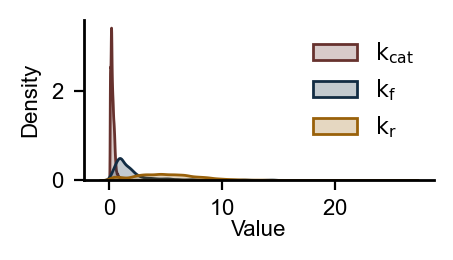

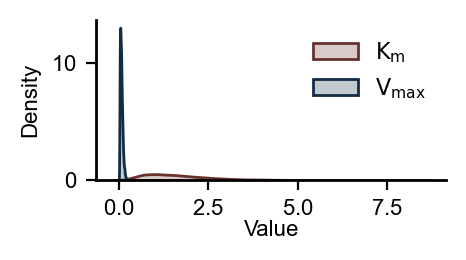

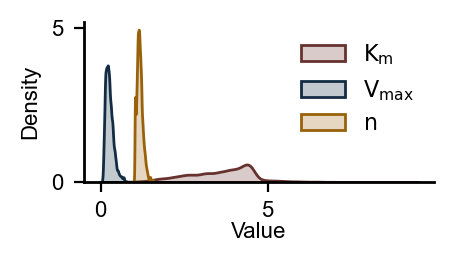

In [119]:
MA_names = {'k_cat': r'$k_{cat}$', 'k_f': r'$k_{f}$', 'k_r': r'$k_{r}$',}
fig, ax = get_sized_fig_ax(1.75, 0.8)
for idx,param in enumerate(list(inf_data_MA.posterior.data_vars.keys())):
    sns.kdeplot(inf_data_MA.posterior[param].values.flatten(), color=colors[idx+1], ax=ax, fill=True, label=MA_names[param], linewidth=1.0)
ax.set_xlabel('Value', fontsize=8)
ax.xaxis.set_label_coords(0.5, -0.25)
ax.set_ylabel('Density', fontsize=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
plt.legend(fontsize=8)
plt.savefig(save_path + 'MA_hist.pdf', transparent=True, bbox_inches='tight')

MM_names = {'V_max': r'$V_{max}$', 'K_m': r'$K_{m}$',}
fig, ax = get_sized_fig_ax(1.75, 0.8)
for idx,param in enumerate(list(inf_data_MM.posterior.data_vars.keys())):
    sns.kdeplot(inf_data_MM.posterior[param].values.flatten(), color=colors[idx+1], ax=ax, fill=True, label=MM_names[param], linewidth=1.0)
ax.set_xlabel('Value', fontsize=8)
ax.xaxis.set_label_coords(0.5, -0.25)
ax.set_ylabel('Density', fontsize=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
plt.legend(fontsize=8)
plt.savefig(save_path + 'MM_hist.pdf', transparent=True, bbox_inches='tight')

Hill_names = {'V_max': r'$V_{max}$', 'K_m': r'$K_{m}$', 'n': r'$n$'}
fig, ax = get_sized_fig_ax(1.75, 0.8)
for idx,param in enumerate(list(inf_data_Hill.posterior.data_vars.keys())):
    sns.kdeplot(inf_data_Hill.posterior[param].values.flatten(), color=colors[idx+1], ax=ax, fill=True, label=Hill_names[param], linewidth=1.0)
ax.set_xlabel('Value', fontsize=8)
ax.xaxis.set_label_coords(0.5, -0.25)
ax.set_ylabel('Density', fontsize=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
plt.legend(fontsize=8)
plt.savefig(save_path + 'Hill_hist.pdf', transparent=True, bbox_inches='tight')


array([[<Axes: >, None],
       [<Axes: xlabel='K_m', ylabel='V_max'>, <Axes: >]], dtype=object)

/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/Users/natetest/miniforge3/envs/pymc/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


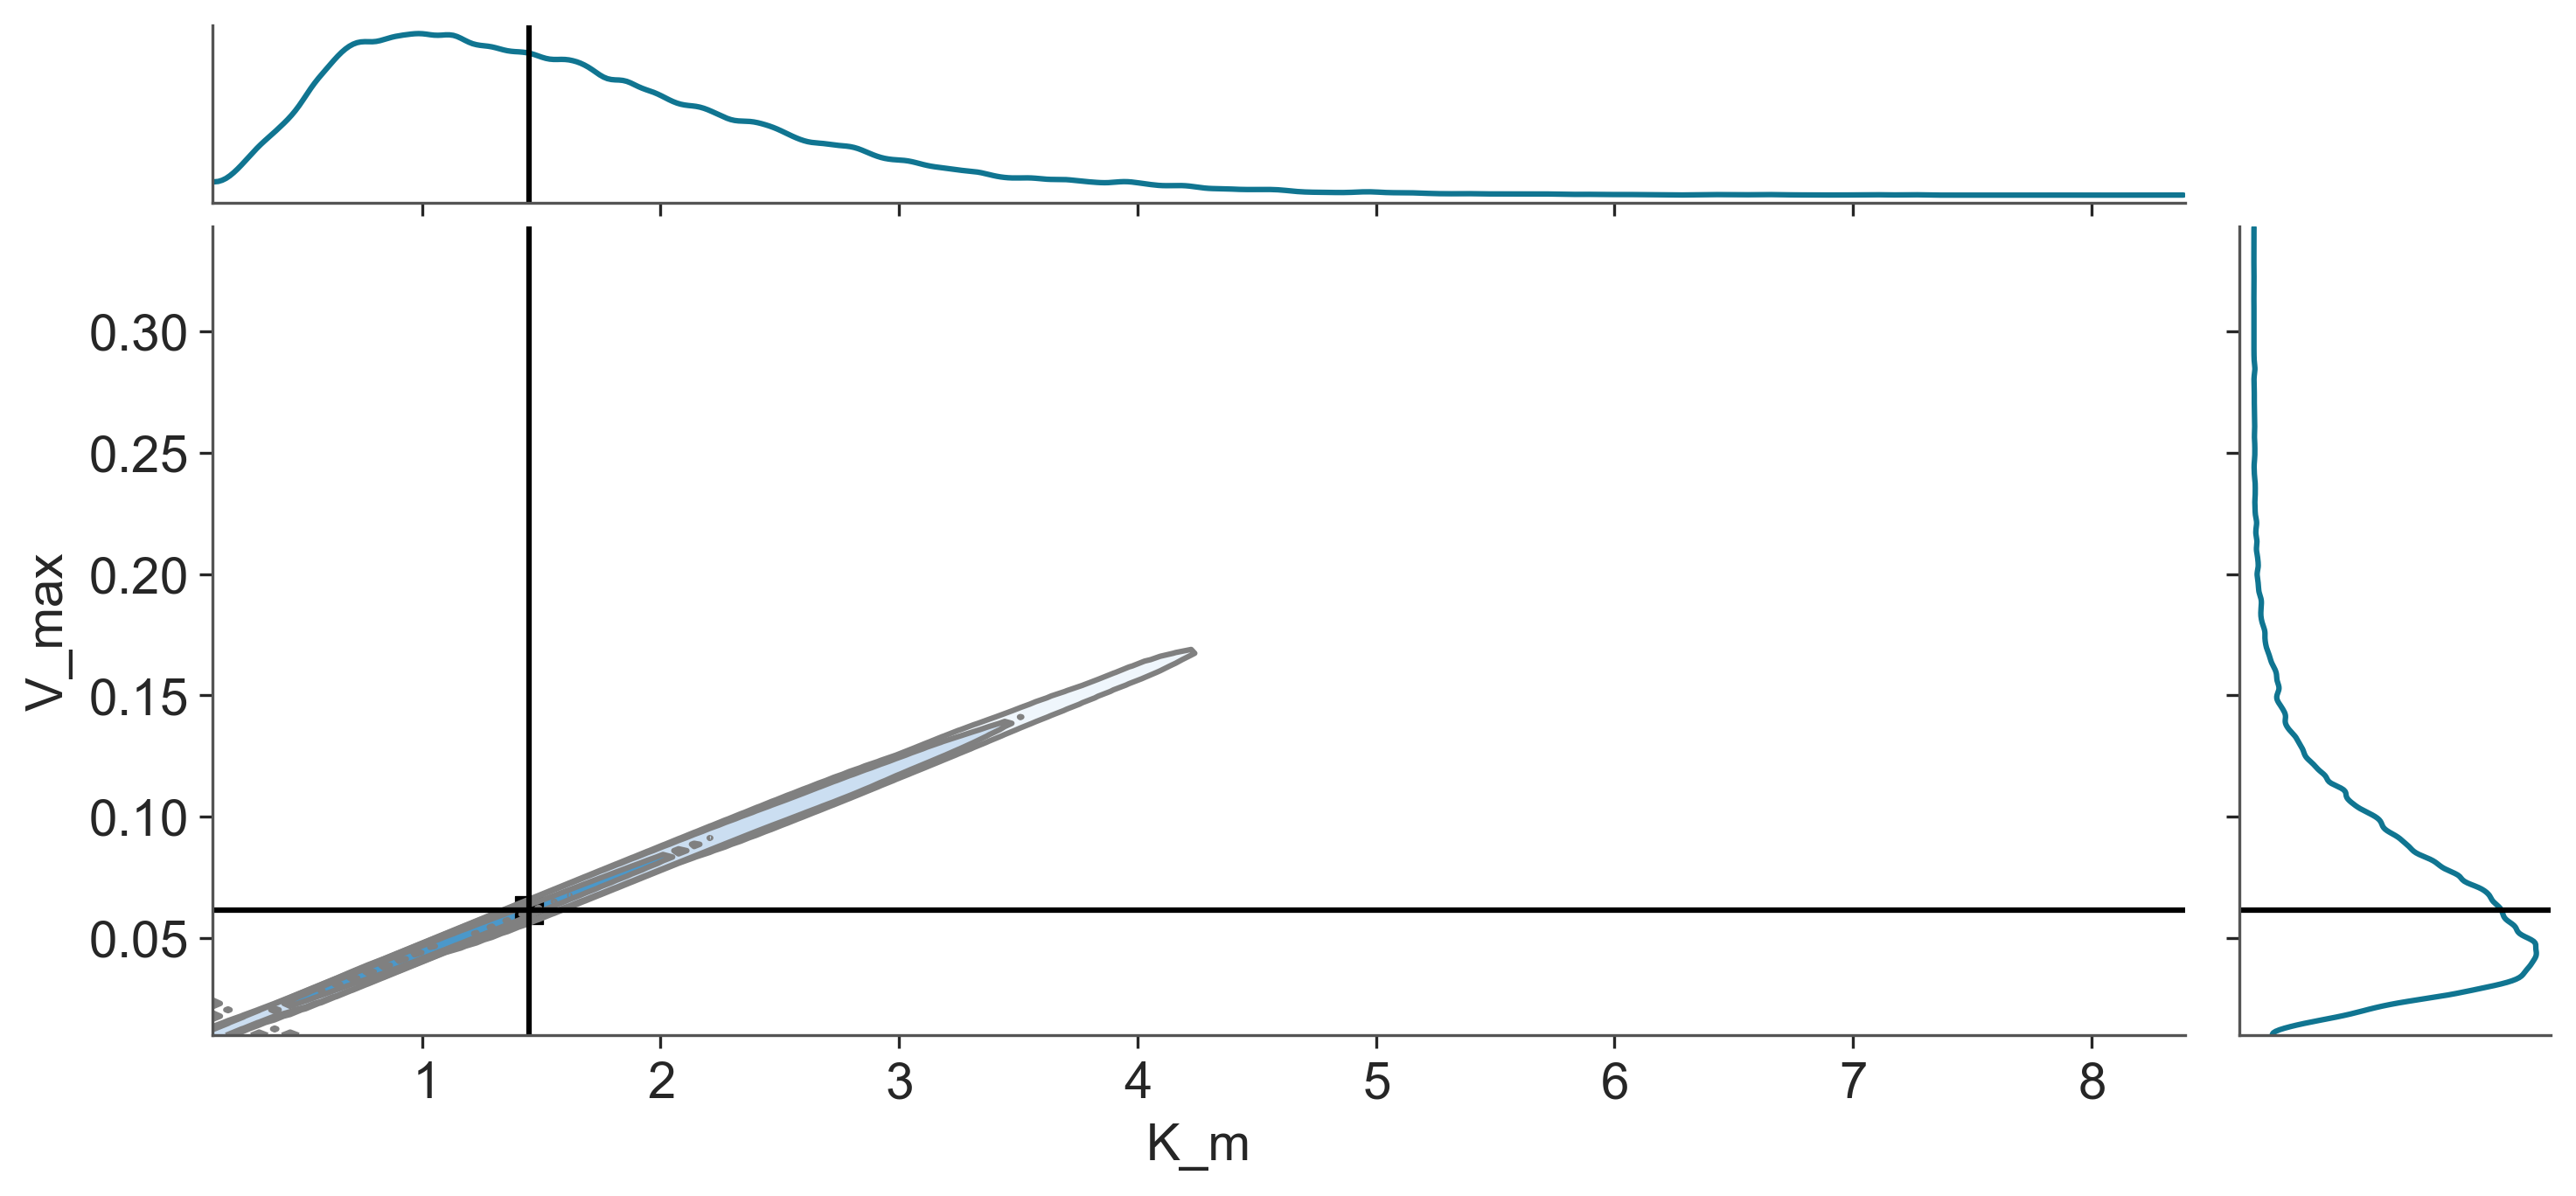

In [10]:
az.style.use("arviz-doc")

az.plot_pair(inf_data_MM,kind="kde",
    kde_kwargs={
        "hdi_probs": [0.3, 0.6, 0.9, 0.95],  # Plot 30%, 60% and 90% HDI contours
        "contourf_kwargs": {"cmap": "Blues"},
    },
    marginals=True,
    point_estimate="median")

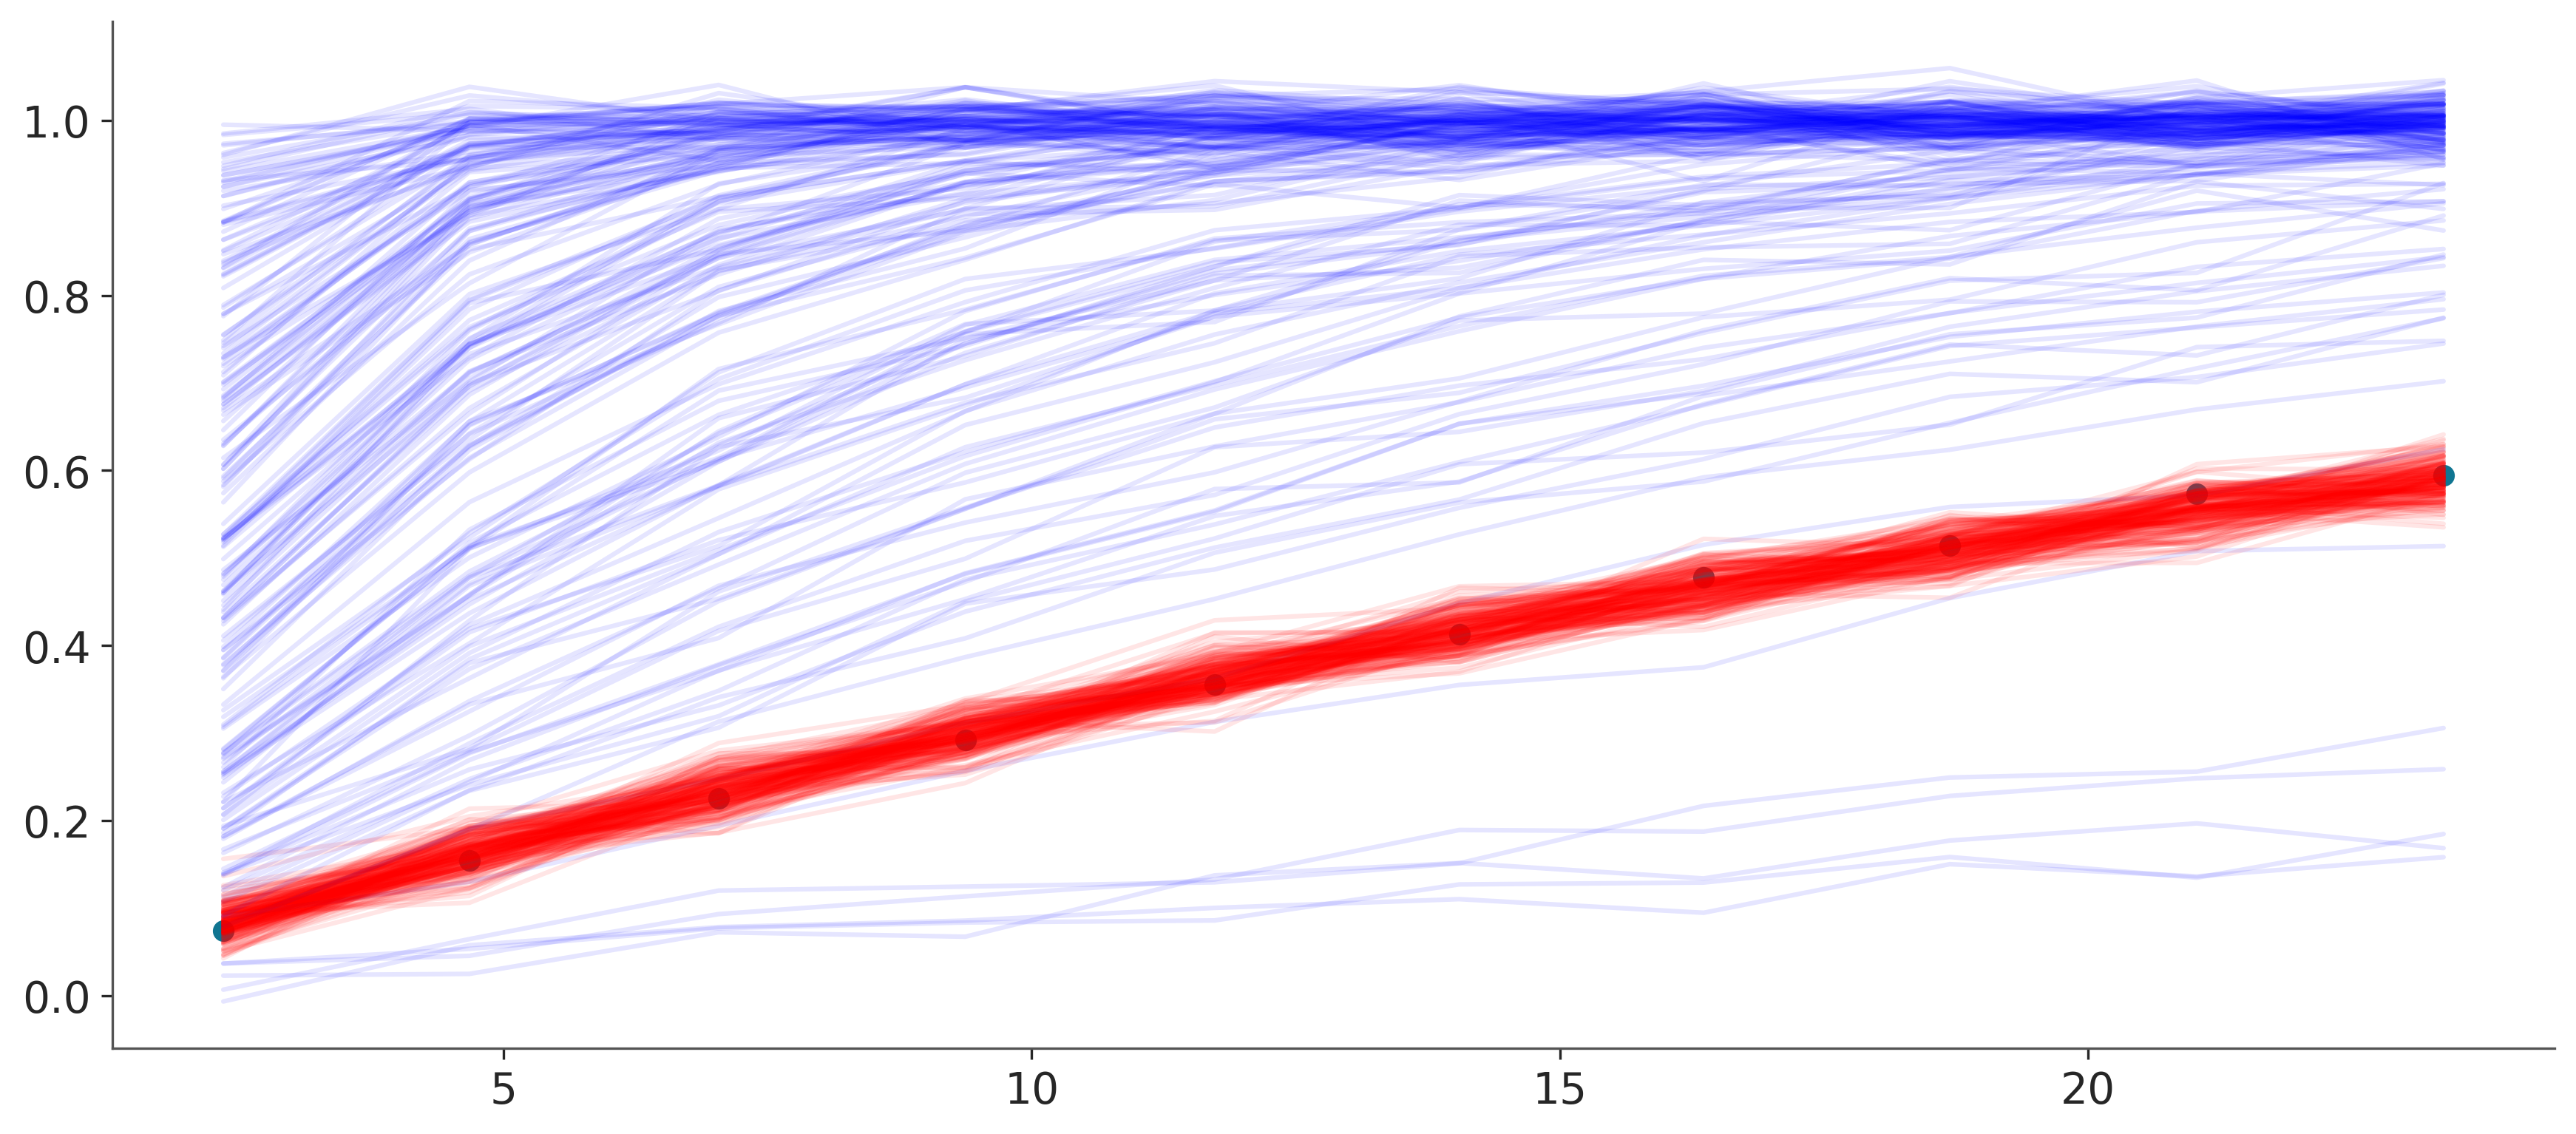

In [17]:
inf_data_MA.posterior_predictive.obs

fig, ax = plt.subplots()
# plot the inferred curve
for i in range(200):
    ax.plot(times, inf_data_MA.prior_predictive.obs[0, i, :], color='blue', alpha=0.1)
    ax.plot(times, inf_data_MA.posterior_predictive.obs[0, i, :], color='red', alpha=0.1)
    # ax.plot(times, inf_data_MM.posterior_predictive.obs[1, i, :], color='red', alpha=0.1)

# plot the data
ax.scatter(times, data)